## Step 1: Loading the dataset

In [6]:
import os
import shutil

from google.colab import drive
drive.mount('/content/drive')

project_dir = "/content/drive/MyDrive/image-classifier-project"
zip_path = os.path.join(project_dir, "dogs-vs-cats.zip")

print("Zip exists:", os.path.exists(zip_path))
size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Zip file size: {size_mb:.2f} MB")


Mounted at /content/drive
Zip exists: True
Zip file size: 554.57 MB


In [7]:
# Extract locally (fast) instead of directly to Drive
local_extract_path = "/content/raw_extracted"
if os.path.exists(local_extract_path):
    shutil.rmtree(local_extract_path)

!unzip -q -o {zip_path} -d {local_extract_path}

inner_path = os.path.join(local_extract_path, "dogs-vs-cats")
sub_path = os.path.join(inner_path, "train")
files = os.listdir(sub_path)
print("Total files:", len(files))

Total files: 25000


In [8]:
import glob
import random

random.seed(42)

organized_path = "/content/data"
for split in ["train", "val"]:
    for label in ["cat", "dog"]:
        os.makedirs(os.path.join(organized_path, split, label), exist_ok=True)

val_fraction = 0.1

for label in ["cat", "dog"]:
    pattern = os.path.join(sub_path, f"{label}.*.jpg")
    label_files = glob.glob(pattern)
    random.shuffle(label_files)

    n_val = int(len(label_files) * val_fraction)
    val_files = label_files[:n_val]
    train_files = label_files[n_val:]

    for f in train_files:
        shutil.copy(f, os.path.join(organized_path, "train", label, os.path.basename(f)))
    for f in val_files:
        shutil.copy(f, os.path.join(organized_path, "val", label, os.path.basename(f)))

    print(f"{label}: {len(train_files)} train, {len(val_files)} val")

cat: 11250 train, 1250 val
dog: 11250 train, 1250 val


## Step 2: Visualize the input information

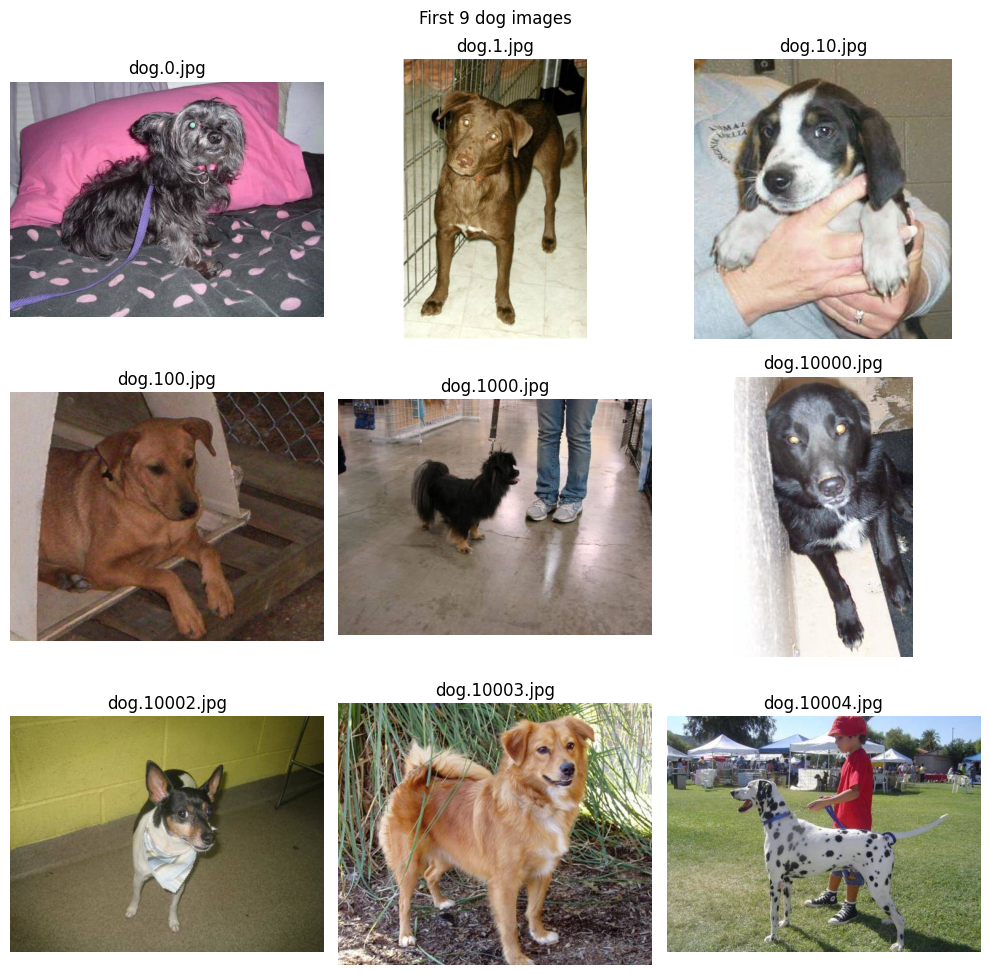

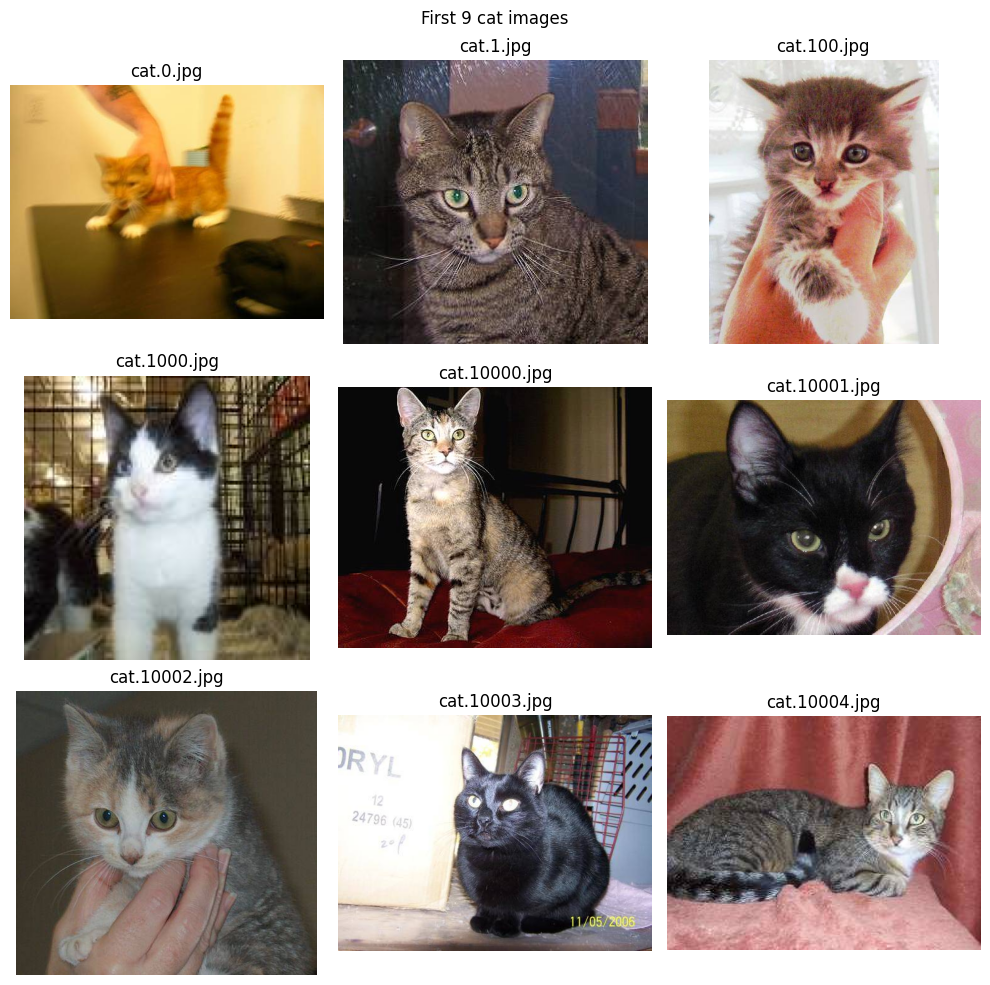

In [9]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def show_first_nine(label):
    folder = os.path.join(organized_path, "train", label)
    filenames = sorted(os.listdir(folder))[:9]

    plt.figure(figsize=(10, 10))
    for i, filename in enumerate(filenames):
        img_path = os.path.join(folder, filename)
        img = image.load_img(img_path)
        plt.subplot(3, 3, i + 1)
        plt.imshow(img)
        plt.title(filename)
        plt.axis("off")
    plt.suptitle(f"First 9 {label} images")
    plt.tight_layout()
    plt.show()

show_first_nine("dog")
show_first_nine("cat")

## Step 3: Build the model

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image_size = (200, 200)
batch_size = 32

# Normalize pixel values (0-255 -> 0-1), which the original tutorial solution skipped
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(organized_path, "train"),
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=["cat", "dog"]
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(organized_path, "val"),
    target_size=image_size,
    batch_size=batch_size,
    class_mode="categorical",
    classes=["cat", "dog"]
)

Found 22500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


In [11]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

# Load VGG16 with pretrained ImageNet weights, without its original classifier head
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(200, 200, 3))

# Freeze the convolutional base so we don't destroy what it already learned
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(units=256, activation="relu"),
    Dense(units=2, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 6, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,434,050 (74.14 MB)

 Trainable params: 4,719,362 (18.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 4: Optimize the model

In [12]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

models_dir = os.path.join(project_dir, "models")
os.makedirs(models_dir, exist_ok=True)
checkpoint_path = os.path.join(models_dir, "vgg16_cats_dogs.keras")

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=1,
    mode="max",
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8534 - loss: 0.4633
Epoch 1: val_accuracy improved from None to 0.92160, saving model to /content/drive/MyDrive/image-classifier-project/models/vgg16_cats_dogs.keras

Epoch 1: finished saving model to /content/drive/MyDrive/image-classifier-project/models/vgg16_cats_dogs.keras
704/704 ━━━━━━━━━━━━━━━━━━━━ 156s 203ms/step - accuracy: 0.8979 - loss: 0.2601 - val_accuracy: 0.9216 - val_loss: 0.1906
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9435 - loss: 0.1433
Epoch 2: val_accuracy did not improve from 0.92160
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 197ms/step - accuracy: 0.9394 - loss: 0.1499 - val_accuracy: 0.9140 - val_loss: 0.2129
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9559 - loss: 0.1162
Epoch 3: val_accuracy did not improve from 0.92160
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 197ms/step - accuracy: 0.9489 - loss: 0.1260 - val_accuracy: 0.9104 - val_loss: 0.2186
Epoch 4/10
70

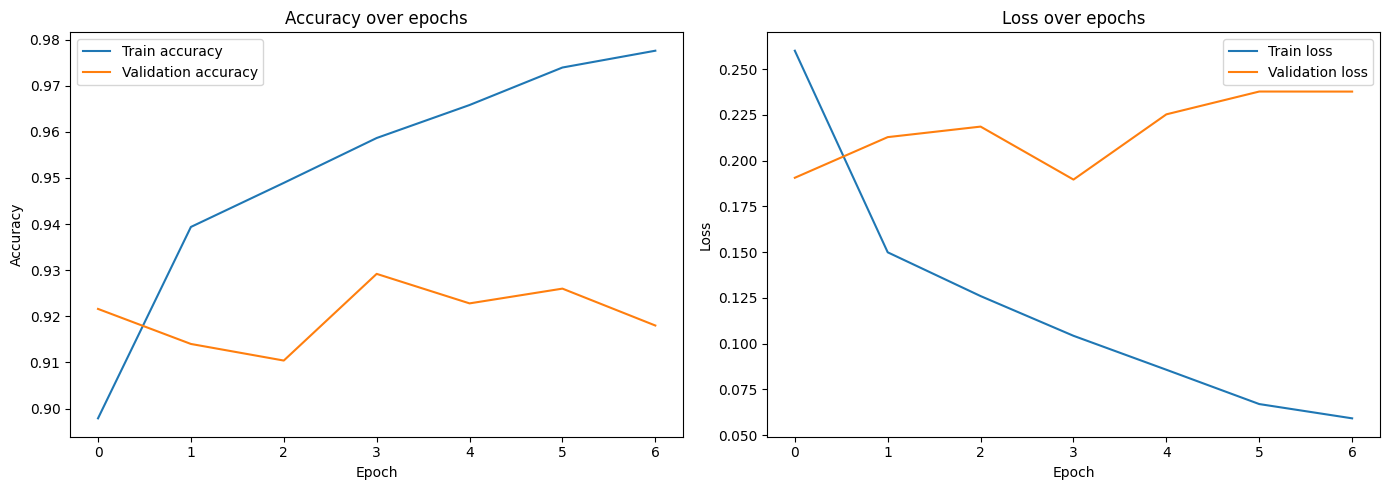

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"], label="Train accuracy")
axes[0].plot(history.history["val_accuracy"], label="Validation accuracy")
axes[0].set_title("Accuracy over epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train loss")
axes[1].plot(history.history["val_loss"], label="Validation loss")
axes[1].set_title("Loss over epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## Step 5: Save and test the model

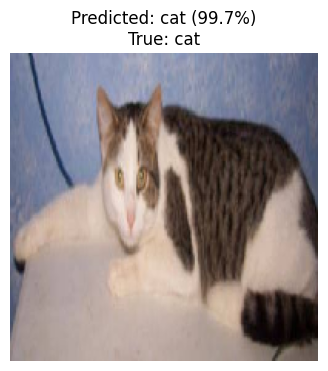

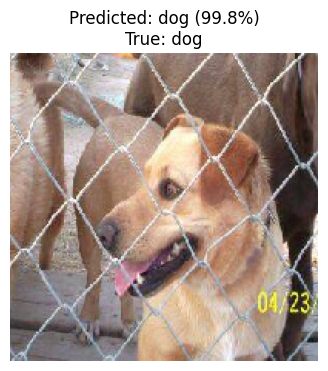

In [14]:
from tensorflow.keras.models import load_model
import numpy as np

# Load the best saved model
saved_model = load_model(checkpoint_path)

def predict_image(img_path, true_label=None):
    img = image.load_img(img_path, target_size=(200, 200))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = saved_model.predict(img_array, verbose=0)
    predicted_label = "cat" if prediction[0][0] > prediction[0][1] else "dog"
    confidence = max(prediction[0])

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    title = f"Predicted: {predicted_label} ({confidence:.1%})"
    if true_label:
        title += f"\nTrue: {true_label}"
    plt.title(title)
    plt.axis("off")
    plt.show()

# Test with a few images from the validation set (we know their true label)
val_cat_folder = os.path.join(organized_path, "val", "cat")
val_dog_folder = os.path.join(organized_path, "val", "dog")

sample_cat = os.path.join(val_cat_folder, os.listdir(val_cat_folder)[0])
sample_dog = os.path.join(val_dog_folder, os.listdir(val_dog_folder)[0])

predict_image(sample_cat, true_label="cat")
predict_image(sample_dog, true_label="dog")